# Individuality dimensions with LDA

In [101]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [102]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# --Machine learning and statistics

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
import umap
from sklearn import mixture
import pickle
from scipy.stats import mode
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from statsmodels.distributions.empirical_distribution import ECDF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import stats
from sklearn.metrics import f1_score
from scipy.stats import zscore

# Get my functions
from functions import get_metadata
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//3_postprocess_results/'
os.chdir(functions_path)
from plotting_functions import create_grouped_gradient_palette

from one.api import ONE
one = ONE(mode='remote')

In [110]:
""" IMPORTANT PATHS """
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/'
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/'
# base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'
base_path = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/'

## Load sequence data

In [142]:
n_paw_states = 8

# Explicit filenames per data type -- add/remove/comment entries to control which data types
# are loaded and combined into the final design matrix (previously done by commenting/
# uncommenting a single `filename` variable below). Fill in the paths you want to use.
data_files = {
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    'raw': base_path + '10_bin_raw_16-06-2026',
    'trial': base_path + 'all_trials_04-05-2026',
}

data_files = {
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    'trial': base_path + 'session_trial_meta_10-07-2026',
}
data_files = {
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    'trial': base_path + 'session_trial_meta_10-07-2026',
}


### Filter data

In [143]:
# Filter out these known-bad sessions and mice with too few sessions -- shared across all
# data types, applied inside build_design_matrix below.
prob_sessions = [
'30af8629-7b96-45b7-8778-374720ddbc5e',
'90e524a2-aa63-47ce-b5b8-1b1941a1223a',
'a8a8af78-16de-4841-ab07-fde4b5281a03',
'49368f16-de69-4647-9a7a-761e94517821',
'a71175be-d1fd-47a3-aa93-b830ea3634a1',
'0deb75fb-9088-42d9-b744-012fb8fc4afb',
'02fbb6da-3034-47d6-a61b-7d06c796a830',
'7f6b86f9-879a-4ea2-8531-294a221af5d0',
'8c33abef-3d3e-4d42-9f27-445e9def08f9',
'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
'510b1a50-825d-44ce-86f6-9678f5396e02']


def filter_sequences(all_sequences):
    print(str(len(all_sequences.mouse_name.unique())) + str(' mice in total'))
    print(str(len(all_sequences.session.unique())) + str(' sessions in total'))

    # FIX: Use drop=True to avoid creating 'index' column
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    print(str(len(all_sequences['session'].unique())) + str(' sessions after removing bad sessions'))

    # Filter out mice without enough sessions
    session_count = all_sequences[['mouse_name', 'session']].drop_duplicates().groupby(['mouse_name'])['session'].count().reset_index()
    multi_sess_mice = session_count.loc[session_count['session']>2, 'mouse_name']

    # FIX: Use drop=True here too
    all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(multi_sess_mice)].reset_index(drop=True)
    print(str(len(multi_sess_mice)) + str(' mice with at least 3 sessions'))
    print(str(len(all_sequences['session'].unique())) + str(' remaining sessions'))

    # Validation
    assert 'index' not in all_sequences.columns, "ERROR: 'index' column created by reset_index!"
    print("✓ Data preparation validated")
    return all_sequences


# Encode syllables for LDA

In [144]:
def binarize(n_features_per_step, use_sequences, n_paw_states=8):
    """
    Binarizes behavioral sequence data dynamically based on the number of paw states.
    
    Parameters:
    -----------
    n_features_per_step : int
        Total features per step *before* dropping the reference column (e.g., 10).
    use_sequences : np.ndarray
        Array of shape (n_trials, timesteps) containing encoded integer states or NaNs.
    n_paw_states : int
        The number of possible paw states (defaults to 8).
    """
    n_trials = use_sequences.shape[0]
    timesteps = use_sequences.shape[1]

    binarized = np.zeros((n_trials, timesteps * n_features_per_step))
    
    for t in range(timesteps):
        current_vals = use_sequences[:, t]
        nan_mask = np.isnan(current_vals)
        valid_mask = ~nan_mask
        labels_0idx = current_vals[valid_mask].astype(int)
        start_col = t * n_features_per_step
        
        if len(labels_0idx) > 0:  
            valid_row_idx = np.arange(n_trials)[valid_mask]
            
            # 1. Fill Paw States (Cols 0 to n_paw_states-1)
            paw_indices = labels_0idx % n_paw_states
            binarized[valid_row_idx, start_col + paw_indices] = 1
            
            # 2. Fill Whisking (Col equal to n_paw_states)
            whisking_col = start_col + n_paw_states
            binarized[valid_mask, whisking_col] = ((labels_0idx // n_paw_states) % 2).astype(int)
            
            # 3. Fill Licking (Col equal to n_paw_states + 1)
            licking_col = start_col + n_paw_states + 1
            binarized[valid_mask, licking_col] = (labels_0idx // (n_paw_states * 2)).astype(int)
        
        # Set all features for this timestep to NaN where original data was NaN
        if np.any(nan_mask):
            feature_cols = slice(start_col, start_col + n_features_per_step)
            binarized[nan_mask, feature_cols] = np.nan

    # Dynamically eliminate Paw State 2 (index 1) for every timestep
    # Using 'n_features_per_step' ensures this steps accurately across the array
    cols_to_delete = [t * n_features_per_step + 1 for t in range(timesteps)]
    binarized_reduced = np.delete(binarized, cols_to_delete, axis=1)
    
    return binarized_reduced

In [145]:
def build_design_matrix(filename, n_paw_states=8):
    """Load one data-type file (syllables / raw / trial, detected from the filename -- same
    branch logic as before, just parameterized instead of hardcoded to a single `filename`)
    and return its per-session-averaged (session_syllables, design_df)."""
    all_sequences = pd.read_parquet(filename)

    if 'syllables' in filename or 'sequences' in filename or 'raw' in filename:
        all_sequences['session'] = all_sequences['sample'].str[:36]

    all_sequences = filter_sequences(all_sequences)

    if 'syllables' in filename or 'sequences' in filename:     
        design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values='binned_sequence').reset_index().dropna()
        # Remove any spurious 'index' column created by reset_index
        if 'index' in design_df.columns:
            design_df = design_df.drop(columns=['index'])
        design_df = design_df.sort_values(by='session')

        # Validate
        assert len(design_df) > 0, "ERROR: design_df is empty after filtering!"
        print(f"✓ design_df created: {len(design_df)} rows, {design_df['mouse_name'].nunique()} mice, {design_df['session'].nunique()} sessions")

        epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
        use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

        # Validate alignment
        assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length ({len(use_sequences)}) != design_df length ({len(design_df)})"

        # --- PARAMETERS ---
        n_features_per_step = n_paw_states + 2  # X Paw + 1 Whisk + 1 Lick
        use_format  = binarize(n_features_per_step, use_sequences, n_paw_states)

    elif 'raw' in filename:
        all_sequences['session'] = all_sequences['sample'].str[:36]
        binned_vars = ['Lick count_binned_sequence', 'whisker_me_binned_sequence', 
                       'l_paw_x_vel_binned_sequence', 'l_paw_y_vel_binned_sequence', 
                       'r_paw_x_vel_binned_sequence', 'r_paw_y_vel_binned_sequence']
        design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values=binned_vars).reset_index().dropna()
        if 'index' in design_df.columns:
            design_df = design_df.drop(columns=['index'])
        design_df = design_df.sort_values(by='session')
        # var_names = design_df.keys()[-4:]
        epoch_to_analyse = design_df.keys()[4:]
        use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

        assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length != design_df length"

        # Normalize
        use_format = zscore(use_sequences, axis=0, nan_policy='omit')

    elif 'trial' in filename:
        design_df = all_sequences.dropna()
        design_df['choice'] = design_df['choice'].map({'left': 0, 'right': 1}).astype(float)
        design_df['feedback'] = design_df['feedback'].map({'incorrect': 0, 'correct': 1}).astype(float)
        bias_df = (design_df[design_df['contrast'] == 0]
                .groupby(['session', 'block'])['choice'].mean()
                .unstack(level='block'))
        bias_df['bias'] = bias_df[0.8] - bias_df[0.2]
        merged = (design_df.groupby(['session', 'mouse_name'])
                .agg({'trial_id': 'count', 'reaction': 'median', 
                      'elongation': 'median', 'feedback': 'mean', 
                      'choice': 'mean', 'p_state1':'mean'
                      })
                .merge(bias_df['bias'], on='session', how='left'))

        merged['log_reaction'], merged['log_elongation'] = np.log(merged['reaction']), np.log(merged['elongation'])
        features = ['trial_id', 'feedback', 'choice', 'p_state1',
                    'log_reaction', 'log_elongation', 'bias']
        # use_format = merged[features].to_numpy()
        # use_format = zscore(use_format, axis=0, nan_policy='omit')
        clean_df = merged[features].dropna()
        use_format = clean_df.to_numpy()
        use_format = zscore(use_format, axis=0)

        design_df = clean_df.reset_index().merge(design_df[['mouse_name', 'session']], on='session').drop_duplicates()

    # Average per session (per data type)
    session_mouse_mapping = design_df[['session', 'mouse_name']].drop_duplicates()
    session_mouse_mapping = session_mouse_mapping.set_index('session')['mouse_name'].to_dict()

    # Validate: each session maps to exactly one mouse
    assert len(session_mouse_mapping) == len(design_df[['session', 'mouse_name']].drop_duplicates()), \
        "ERROR: A session maps to multiple mice!"

    session_syllables = pd.DataFrame(use_format)
    session_syllables['session'] = design_df['session'].values
    session_syllables = session_syllables.groupby('session', sort=False)[np.arange(0, np.shape(use_format)[1], 1)].mean()

    # Create mouse name labels using explicit mapping
    mouse_names_list = np.array([session_mouse_mapping[sess] for sess in session_syllables.index])

    print(f"✓ Session aggregation complete: {len(session_syllables)} sessions")
    print(f"✓ Mouse labels: {dict(zip(*np.unique(mouse_names_list, return_counts=True)))}")

    return session_syllables, design_df


## Average per session

In [146]:
results = {}
for data_type, filename in data_files.items():
    print(f'--- {data_type}: {filename} ---')
    session_syllables_i, design_df_i = build_design_matrix(filename, n_paw_states=n_paw_states)
    # Prefix columns with the data type so integer column names from different types
    # (0, 1, 2, ...) don't collide when appended together below.
    results[data_type] = {
        'session_syllables': session_syllables_i.add_prefix(f'{data_type}_'),
        'design_df': design_df_i,
    }

# Append (column-wise) into one combined design matrix -- inner join keeps only sessions
# present in every loaded data type.
session_syllables = pd.concat([r['session_syllables'] for r in results.values()], axis=1, join='inner')
design_df = pd.concat([r['design_df'][['mouse_name', 'session']] for r in results.values()],
                       ignore_index=True).drop_duplicates()

print(f"✓ Combined design matrix: {len(session_syllables)} sessions, {session_syllables.shape[1]} features "
      f"(data types: {list(data_files.keys())})")


--- syllables: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/8_k_10_bin_syllables_17-06-2026 ---
102 mice in total
318 sessions in total
307 sessions after removing bad sessions
56 mice with at least 3 sessions
248 remaining sessions
✓ Data preparation validated
✓ design_df created: 154367 rows, 56 mice, 248 sessions
✓ Session aggregation complete: 248 sessions
✓ Mouse labels: {'CSHL045': 5, 'CSHL049': 4, 'CSHL052': 4, 'CSHL053': 3, 'CSHL058': 3, 'CSHL059': 5, 'CSHL060': 5, 'CSH_ZAD_019': 3, 'CSH_ZAD_026': 6, 'CSH_ZAD_029': 4, 'DY_009': 9, 'DY_010': 4, 'DY_011': 4, 'DY_014': 6, 'DY_016': 5, 'DY_018': 3, 'DY_020': 8, 'NR_0019': 3, 'NR_0020': 4, 'NR_0021': 3, 'NR_0027': 4, 'NYU-30': 3, 'NYU-39': 5, 'NYU-40': 4, 'NYU-45': 3, 'NYU-46': 4, 'NYU-47': 3, 'NYU-48': 3, 'NYU-65': 3, 'PL015': 4, 'PL017': 6, 'PL030': 7, 'PL031': 4, 'PL033': 13, 'PL034': 3, 'SWC_043': 7, 'SWC_052': 7, 'SWC_053': 3, 'SWC_054': 6, 'SWC_058': 4, 'SWC_060': 3,

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_66362/2387942393.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  design_df['choice'] = design_df['choice'].map({'left': 0, 'right': 1}).astype(float)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_66362/2387942393.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  design_df['feedback'] = design_df['feedback'].map({'incorrect': 0, 'correct': 1}).astype(float)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/pandas/core/array

✓ Session aggregation complete: 241 sessions
✓ Mouse labels: {'CSHL045': 5, 'CSHL049': 4, 'CSHL052': 4, 'CSHL053': 3, 'CSHL058': 3, 'CSHL059': 5, 'CSHL060': 5, 'CSH_ZAD_019': 3, 'CSH_ZAD_026': 6, 'CSH_ZAD_029': 4, 'DY_009': 9, 'DY_010': 4, 'DY_011': 4, 'DY_014': 6, 'DY_016': 5, 'DY_018': 3, 'DY_020': 8, 'NR_0019': 3, 'NR_0020': 4, 'NR_0021': 3, 'NR_0027': 4, 'NYU-30': 3, 'NYU-39': 5, 'NYU-40': 4, 'NYU-45': 2, 'NYU-46': 4, 'NYU-47': 3, 'NYU-48': 3, 'NYU-65': 3, 'PL015': 4, 'PL017': 6, 'PL030': 7, 'PL031': 4, 'PL033': 13, 'PL034': 3, 'SWC_043': 7, 'SWC_052': 7, 'SWC_053': 3, 'SWC_054': 6, 'SWC_058': 4, 'SWC_060': 3, 'SWC_061': 3, 'UCLA033': 3, 'UCLA034': 4, 'UCLA037': 4, 'ZFM-01577': 3, 'ZFM-01592': 3, 'ZFM-01935': 4, 'ZFM-01936': 5, 'ZM_2240': 3, 'ZM_2241': 4, 'ibl_witten_26': 4, 'ibl_witten_27': 3, 'ibl_witten_29': 9}
✓ Combined design matrix: 241 sessions, 367 features (data types: ['syllables', 'trial'])


Text(0, 0.5, 'Sessions')

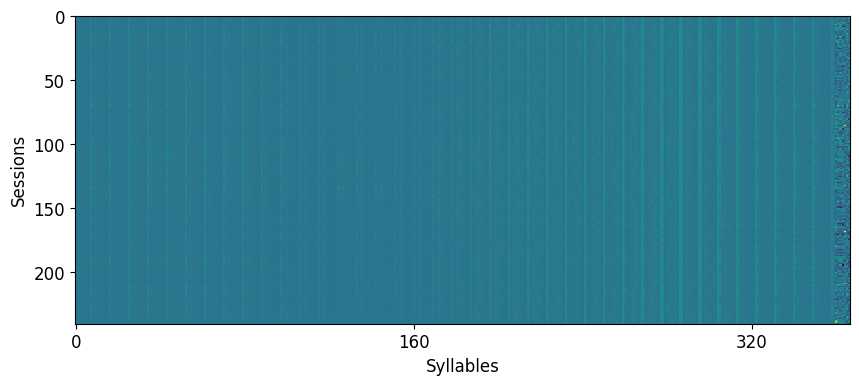

In [147]:
plt.figure(figsize=(10, 4))
plt.imshow(np.array(session_syllables), aspect='auto', cmap='viridis', interpolation='none')
plt.xticks(np.arange(0, session_syllables.shape[1], 160), np.arange(0, session_syllables.shape[1], 160))
plt.xlabel('Syllables')
plt.ylabel('Sessions')

# Dimensionality reduction

In [148]:
all_features = session_syllables.copy()

16 components explain 0.95 of total variance


Text(0.5, 1.0, 'Explained Variance by PCA')

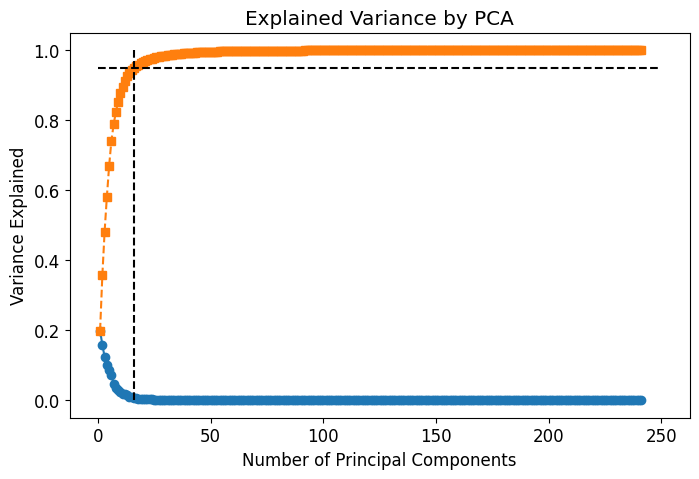

In [149]:
# PCA
n_components = np.min([np.shape(np.array(all_features))[0], np.shape(np.array(all_features))[1]])
# Step 1: Reduce dimensions with PCA
pca = PCA(n_components)  # Reduce to 50 dimensions
scaler = StandardScaler()
# standardized_X = scaler.fit_transform(np.array(all_features))
# X_pca = pca.fit_transform(standardized_X)
X_pca = pca.fit_transform(np.array(all_features))

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
threshold = 0.95
min_components = np.where(cumulative_variance>threshold)[0][0]
# min_components = 26
print(str(min_components) + ' components explain ' + str(threshold) +' of total variance')

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
plt.hlines(threshold, 0, 250, 'black', 'dashed')
plt.vlines(min_components, 0, 1, 'black', 'dashed')
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by PCA")

In [159]:
min_components = 10


In [160]:
mat = np.array(session_syllables.copy())
mat = np.array(X_pca[:, :min_components])

scaler = StandardScaler()
norm_pop = scaler.fit_transform(mat.copy())

# LDA

In [161]:
mapping = pd.DataFrame(np.array(design_df[['mouse_name', 'session']].drop_duplicates()), columns=['mouse_name', 'session'])
df_with_sessions = session_syllables.reset_index()
mouse_names = df_with_sessions.merge(mapping, on=['session'])['mouse_name']
df = df_with_sessions.merge(mapping, on=['session'])

In [162]:
n_per_mouse = 3
lda_components = 30
lda_components = np.min([min_components, len(mouse_names.unique())-1])
# lda_components = 30
n_repeats = 10

final_matrix = np.array(norm_pop)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]
n_samples = X.shape[0]
rng = np.random.default_rng(0)

# Store repeat results
true_scores_all = []
shuffle_scores_all = []

for repeat in range(n_repeats):
    scores_true = []
    scores_shuff = []

    # Subsample balanced sessions for training in each fold
    for test_idx in range(n_samples):
        X_test = X[test_idx:test_idx+1]
        y_test = y[test_idx:test_idx+1]
        train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
        X_train_full = X[train_idx]
        y_train_full = y[train_idx]

        # --- balanced subsampling for training ---
        balanced_idx = []
        for m in np.unique(y_train_full):
            m_idx = np.where(y_train_full == m)[0]
            if len(m_idx) >= n_per_mouse-1:
                balanced_idx.extend(rng.choice(m_idx, n_per_mouse-1, replace=False))
            # else:
                # print(m)
        balanced_idx = np.array(balanced_idx)
        X_train = X_train_full[balanced_idx]
        y_train = y_train_full[balanced_idx]

        # --- true labels run ---
        lda = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train))) / len(np.unique(y_train)),
            n_components=lda_components)
        lda.fit(X_train, y_train)
        scores_true.append(lda.score(X_test, y_test))

        # --- shuffled labels run ---
        y_train_shuff = y_train.copy()
        rng.shuffle(y_train_shuff)
        lda_shuff = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train_shuff))) / len(np.unique(y_train_shuff)),
            n_components=lda_components)
        lda_shuff.fit(X_train, y_train_shuff)
        scores_shuff.append(lda_shuff.score(X_test, y_test))
        
    # store average score for this repeat
    true_scores_all.append(np.mean(scores_true))
    shuffle_scores_all.append(np.mean(scores_shuff))

print("True labels mean ± std:", np.mean(true_scores_all), np.std(true_scores_all))
print("Shuffled labels mean ± std:", np.mean(shuffle_scores_all), np.std(shuffle_scores_all))

True labels mean ± std: 0.49211618257261414 0.028819510961303474
Shuffled labels mean ± std: 0.01950207468879668 0.010172324209237563


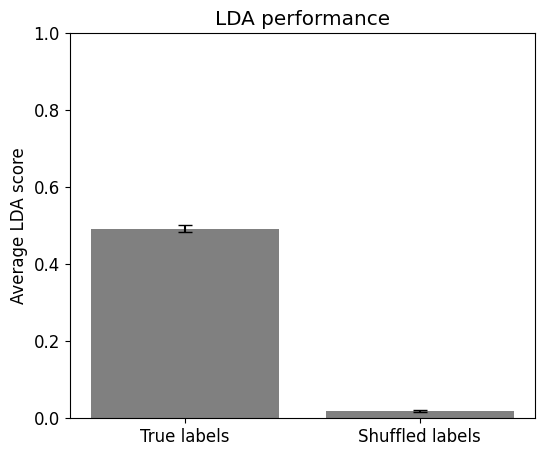

In [163]:
# Convert to arrays for convenience
true_scores = np.array(true_scores_all)
shuffle_scores = np.array(shuffle_scores_all)

# Compute means and standard deviations
means = [np.mean(true_scores), np.mean(shuffle_scores)]
stds  = [np.std(true_scores), np.std(shuffle_scores)]
std_errs = [np.std(true_scores)/np.sqrt(len(true_scores)), 
            np.std(shuffle_scores)/np.sqrt(len(shuffle_scores))]

labels = ['True labels', 'Shuffled labels']

# Create bar plot with error bars
plt.figure(figsize=(6,5))
plt.bar(labels, means, yerr=std_errs, color='grey', capsize=5) #, color=['skyblue','lightcoral']
plt.ylabel('Average LDA score')
plt.title('LDA performance')
plt.ylim(0,1)
# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'lda_score.svg', format='svg', bbox_inches='tight')
plt.show()

### Rerun for analyses

In [75]:
n_per_mouse = 3
lda_components = 30
lda_components = min_components

# final_matrix = np.array(norm_array)
final_matrix = np.array(norm_pop)
# final_matrix = np.array(mat)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]
n_samples = X.shape[0]
rng = np.random.default_rng(0)

# Subsample balanced sessions for training in each fold
for test_idx in range(n_samples):

    X_test = X[test_idx:test_idx+1]
    y_test = y[test_idx:test_idx+1]

    train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
    X_train_full = X[train_idx]
    y_train_full = y[train_idx]

    # --- balanced subsampling for training ---
    balanced_idx = []
    for m in np.unique(y_train_full):
        m_idx = np.where(y_train_full == m)[0]
        if len(m_idx) >= n_per_mouse:
            balanced_idx.extend(rng.choice(m_idx, n_per_mouse, replace=False))
        else:
            print(m)

    balanced_idx = np.array(balanced_idx)
    X_train = X_train_full[balanced_idx]
    y_train = y_train_full[balanced_idx]

    X_train = X_train_full
    y_train = y_train_full

0
42
42
42
42
4
42
42
42
42
8
42
42
10
42
42
42
13
42
42
15
42
42
42
42
42
18
42
42
42
42
0
42
42
15
42
42
18
42
42
22
42
13
42
42
42
42
42
42
42
8
42
42
42
27
42
42
42
42
42
42
32
42
42
33
42
42
42
42
42
42
42
42
42
42
42
27
42
37
42
42
42
42
42
42
42
42
42
42
42
42
42
42
43
8
42
42
42
45
42
42
47
42
42
37
42
42
42
47
42
4
42
42
45
42
42
42
42
42
48
4
42
42
42
42
42
42
42
42
42
42
42
42
42
32
42
42
42
42
42
42
42
42
42
50
42
42
42
47
0
42
42
42
45
42
42
42
42
42
10
42
42
51
42
42
42
42
42
42
51
32
42
42
42
42
42
52
42
42
42
42
42
42
33
42
42
42
42
50
42
42
42
48
42
42
42
42
42
42
42
52
42
33
42
42
42
42
42
42
42
42
42
42
48
42
42
52
42
42
42
42
42
42
42
42
42
42
42
43
42
42
42
42
42
42
42
42
42
15
42
42
42
27
42
42
42
42
51
42
42
42
42
42
18
42
42
42
42
42
43
42
42
42
37
42
42
42
42
42
10
42
42
42
42
42
42
42
50
22
42
42
42
42
42
42
42
42
42
42
22
42
42
42
13
42
42
42
42


# Fit for visualization

In [76]:
final_matrix = np.array(norm_pop)

In [77]:
# --- fit LDA ---
lda = LinearDiscriminantAnalysis(priors=np.ones(len(np.unique(y_train))) / 
                                    len(np.unique(y_train)), n_components=lda_components)

lda.fit(X_train, y_train)
# lda.fit(X_train_full, y_train_full)

# final_matrix = np.array(norm_array[:, :np.shape(X_train)[1]])
X = final_matrix.copy()

final_transformed = lda.transform(X)
clustered = pd.DataFrame(final_transformed)
clustered['mouse_name'] = mouse_names
clustered['mouse_number'] = pd.factorize(clustered['mouse_name'])[0]
# clustered['lab'] = lab_id
# clustered['lab_number'] = pd.factorize(clustered['lab'])[0]
# clustered['litter_id'] = litter_id
# clustered['litter_number'] = pd.factorize(clustered['litter_id'])[0]
clustered['session'] = session_syllables.reset_index()['session']

# clustered = clustered.merge(cluster_df[['mouse_name', 'mouse_cluster']].drop_duplicates(), on=['mouse_name'])

In [78]:
len(clustered.mouse_name.unique())

54

In [79]:
# 1. Get LDA weights in PC space
# Shape: (1, n_components)
w_pca = lda.coef_[0:1, :]
# 2. Back-project to original flattened space
# pca.components_ shape: (n_components, n_original_features)
# n_original_features is (40 timesteps * 9/10 syllables)
weights = np.dot(w_pca, pca.components_[:min_components, :])
# To get one "Global Importance" value per feature across all mice:
# We take the root-mean-square (or L2 norm) across the 38 discriminant dimensions
global_importance = np.sqrt(np.mean(weights**2, axis=0))
global_importance = weights

# Reshape to (40 timesteps, 9 syllables)
reshaped_weights = global_importance.reshape(40, n_paw_states-1+2)

# Now you can identify which feature is which
paw_importance = reshaped_weights[:, :n_paw_states-1]  # First 7 columns
whisk_importance = reshaped_weights[:, n_paw_states-1] # 8th column
lick_importance = reshaped_weights[:, n_paw_states]  # 9th column

plt.figure(figsize=(12, 5))
timesteps = 40
time_axis = np.arange(timesteps)

# Plot average importance of Paw states vs Whisk vs Lick
palette = sns.color_palette('Set3', n_paw_states)
for i, state in enumerate([0, 2, 3, 4, 5, 6, 7]):
    plt.plot(time_axis, paw_importance[:, i], label=f'Paw {state}', color=palette[state], alpha=1, lw=1.5)
    
plt.plot(time_axis, np.abs(whisk_importance), color="#b8b8b8", label='Whisk Importance', linewidth=2)
plt.plot(time_axis, np.abs(lick_importance), color="#484949", label='Lick Importance', linewidth=2)

plt.vlines(10, -10, 30, color='k', linestyle='--', label='Quiescence')
plt.vlines(20, -10, 30, color='k', linestyle='--', label='Stimulus')
plt.vlines(30, -10, 30, color='k', linestyle='--', label='Responde')

plt.ylim([-2, 4])
plt.title('Feature Importance (LDA Weights) Over Time')
plt.xlabel('Timestep')
plt.ylabel('Absolute Weight Magnitude')
plt.legend(
    title='Fingerprint',
    bbox_to_anchor=(1.05, .8),
    loc='upper left')
plt.show()

ValueError: cannot reshape array of size 7 into shape (40,9)

### Structural coefficients

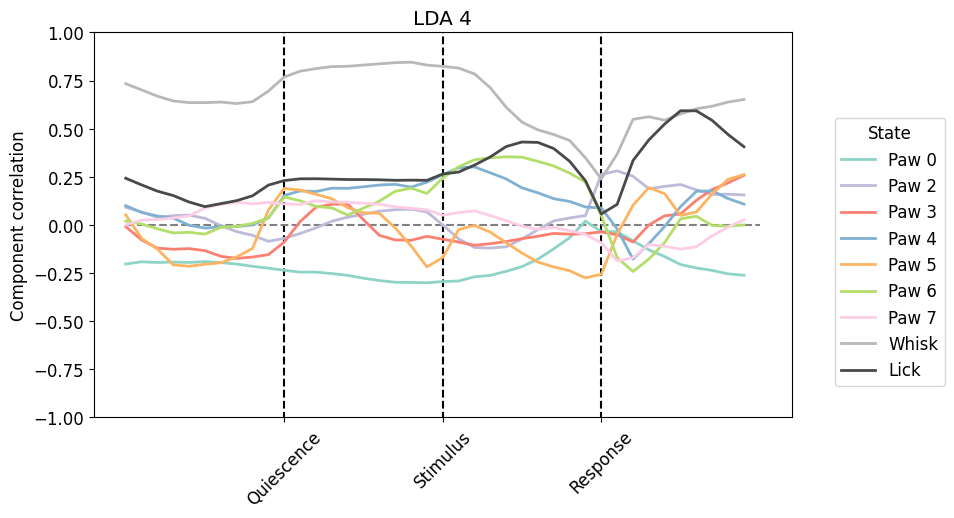

In [159]:
# 1. Get the LDA scores for all trials (their position on the LD1 axis)
lda_scores = final_transformed

# # 2. Correlate each original syllable (360 features) with those scores
from scipy.stats import pearsonr
# struct_coeffs = np.array([pearsonr(np.array(session_syllables)[:, i], lda_scores)[0] for i in range(360)])
# Use .ravel() or [:, i] ensuring the array is 1D
struct_coeffs = np.array([
    pearsonr(np.array(session_syllables)[:, i], lda_scores[:, 0])[0] 
    for i in range(np.array(session_syllables).shape[1])])

# 3. Reshape and plot
reshaped_struct = struct_coeffs.reshape(40, n_paw_states-1+2)

plt.figure(figsize=(9, 5))
time_axis = np.arange(timesteps)

# Now you can identify which feature is which
paw_importance = reshaped_struct[:, :n_paw_states-1]  # First 7 columns
whisk_importance = reshaped_struct[:, n_paw_states-1] # 8th column
lick_importance = reshaped_struct[:, n_paw_states]  # 9th column


plt.vlines(10, -10, 30, color='k', linestyle='--')
plt.vlines(20, -10, 30, color='k', linestyle='--')
plt.vlines(30, -10, 30, color='k', linestyle='--')
plt.hlines(0, -0, 40, color='grey', linestyle='--')

palette = sns.color_palette('Set3', n_paw_states)
for i, state in enumerate([0, 2, 3, 4, 5, 6, 7]):
    plt.plot(time_axis, paw_importance[:, i], label=f'Paw {state}', color=palette[state], alpha=1, lw=2)

plt.plot(time_axis, (whisk_importance), color="#b8b8b8", label='Whisk', linewidth=2)
plt.plot(time_axis, (lick_importance), color="#484949", label='Lick', linewidth=2)

plt.ylim([-1, 1])
plt.title('LDA 4')
# plt.xlabel('Timestep')
plt.ylabel('Component correlation')
plt.legend(
    title='State',
    bbox_to_anchor=(1.05, .8),
    loc='upper left')
plt.xticks([10, 20, 30], ['Quiescence', 'Stimulus', 'Response'], rotation=45)
# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'feature_importances_lda.svg', format='svg', bbox_inches='tight')
plt.show()

# Save data

In [160]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
current_date = datetime.now().strftime('%d-%m-%Y')
filename = f"mouse_LDA_5_bins_cut{current_date}"
clustered['binned1'] = pd.cut(clustered[0], 5)
clustered['binned2'] = pd.cut(clustered[1], 5)
clustered['binned3'] = pd.cut(clustered[2], 5)
clustered['binned4'] = pd.cut(clustered[3], 5)
clustered['binned5'] = pd.cut(clustered[4], 5)
import pickle
# pickle.dump(open(results_df, 'wb'), filename)
clustered.to_pickle(data_path+filename)  

In [57]:
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# filename = "mouse_LDA_quadrants"
# clustered.loc[(clustered[0]<0) & (clustered[1]<0), 'quadrant'] = 3
# clustered.loc[(clustered[0]>0) & (clustered[1]>0), 'quadrant'] = 1
# clustered.loc[(clustered[0]>0) & (clustered[1]<0), 'quadrant'] = 2
# clustered.loc[(clustered[0]<0) & (clustered[1]>0), 'quadrant'] = 4
# import pickle
# # pickle.dump(open(results_df, 'wb'), filename)
# clustered.to_pickle(data_path+filename) 

In [ ]:
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# filename = "mouse_LDA_quadrants"

# clustered['binned1'] = pd.cut(clustered[0], 3)
# clustered['binned2'] = pd.cut(clustered[1], 3)
# clustered['binned3'] = pd.cut(clustered[2], 3)
# # clustered['binned4'] = pd.cut(clustered[3], 5)
# # clustered['binned5'] = pd.cut(clustered[4], 5)
# import pickle
# # pickle.dump(open(results_df, 'wb'), filename)
# # clustered.to_pickle(data_path+filename)  

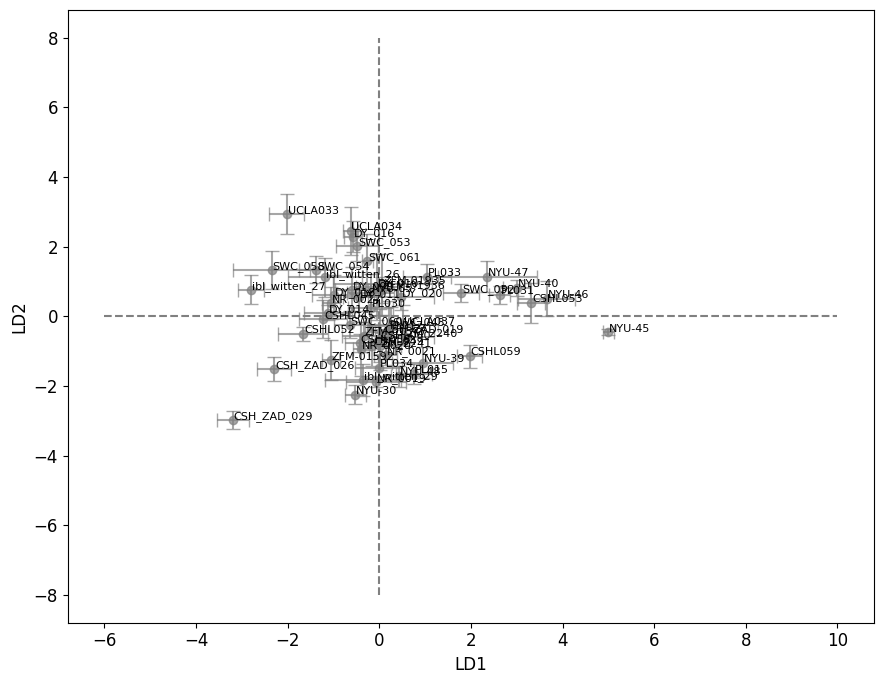

In [80]:
plt.figure(figsize=(9,7))
colors = sns.color_palette('tab20') + sns.color_palette('Set3') + sns.color_palette('Pastel1')
colors = colors[:60]

plt.rc('font', size=12, weight='normal')
df_lda = clustered.copy()  # your LDA-projected dataframe
# Group by mouse
grouped = df_lda.groupby(['mouse_name', 'mouse_number'])
# Compute mean and std for each mouse
mouse_means = grouped[[0, 1, 2]].mean()
mouse_stds  = grouped[[0, 1, 2]].std()/np.sqrt(4)

for mouse in mouse_means.index:
    mean_vals = mouse_means.loc[mouse]
    std_vals = mouse_stds.loc[mouse]
    x = mean_vals[0]
    y = mean_vals[1]
    plt.errorbar(
        x, y,
        xerr=std_vals[0], yerr=std_vals[1],
        fmt='o', capsize=5,
        color='grey', alpha=0.7)  # colors[mouse[4]]

    # Add label next to point
    plt.text(
        x + 0.02, y + 0.02,          # small offset so text isn't on top of the dot
        str(mouse[0]),               # mouse name
        fontsize=8)
plt.vlines(0, -8, 8, color='grey', linestyle='--')
plt.hlines(0, -6, 10, color='grey', linestyle='--')
# plt.scatter(archetypes.T[0], archetypes.T[1], color='black')
# plt.plot(
#     np.concatenate([archetypes.T[0], [archetypes.T[0][0]]]),
#     np.concatenate([archetypes.T[1], [archetypes.T[1][0]]]),
#     color='grey')

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.grid(False)
plt.tight_layout()
plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'lda12_mice.svg', format='svg', bbox_inches='tight')
plt.show()

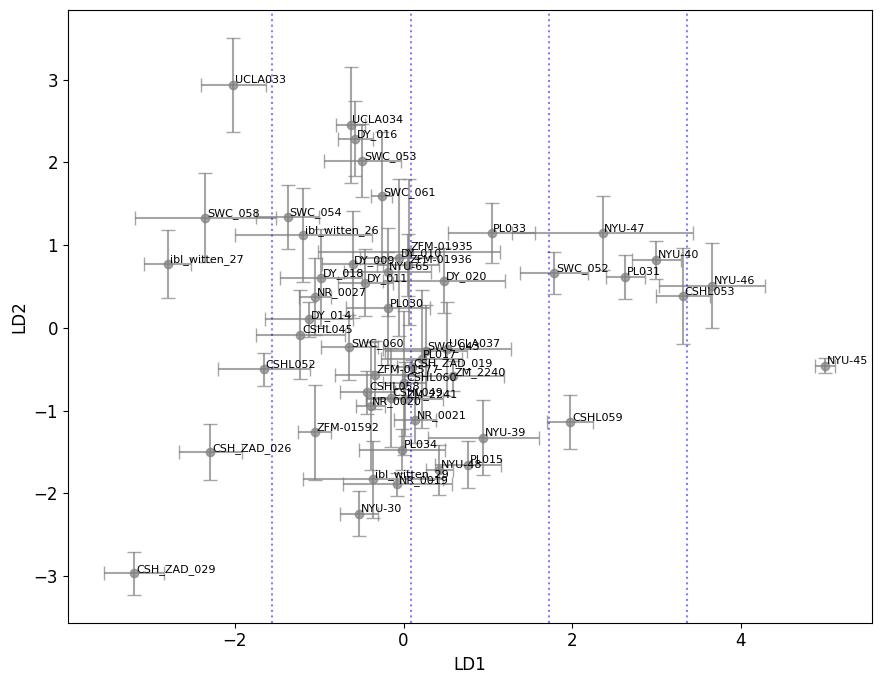

In [81]:
plt.figure(figsize=(9,7))
colors = sns.color_palette('tab20') + sns.color_palette('Set3') + sns.color_palette('Pastel1')
colors = colors[:60]

plt.rc('font', size=12, weight='normal')

for mouse in mouse_means.index:
    mean_vals = mouse_means.loc[mouse]
    std_vals = mouse_stds.loc[mouse]
    x = mean_vals[0]
    y = mean_vals[1]
    plt.errorbar(
        x, y,
        xerr=std_vals[0], yerr=std_vals[1],
        fmt='o', capsize=5,
        color='grey', alpha=0.7)  # colors[mouse[4]]

    # Add label next to point
    plt.text(
        x + 0.02, y + 0.02,          # small offset so text isn't on top of the dot
        str(mouse[0]),               # mouse name
        fontsize=8)

# plt.vlines(0, -8, 8, color='grey', linestyle='--')
# plt.hlines(0, -6, 10, color='grey', linestyle='--')

# Add bin edges for 5 bins on each axis
x_vals = mouse_means.iloc[:, 0]
y_vals = mouse_means.iloc[:, 1]

x_bins = pd.cut(x_vals, bins=5, retbins=True)[1]
y_bins = pd.cut(y_vals, bins=5, retbins=True)[1]

for xb in x_bins[1:-1]:  # skip outermost edges
    plt.axvline(xb, color='blue', linestyle=':', alpha=0.5)

# for yb in y_bins[1:-1]:
#     plt.axhline(yb, color='red', linestyle=':', alpha=0.5)

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.grid(False)
plt.tight_layout()

In [82]:
np.sum(lda.explained_variance_ratio_)

0.9999999999999999

Text(0.5, 0, 'LDA components')

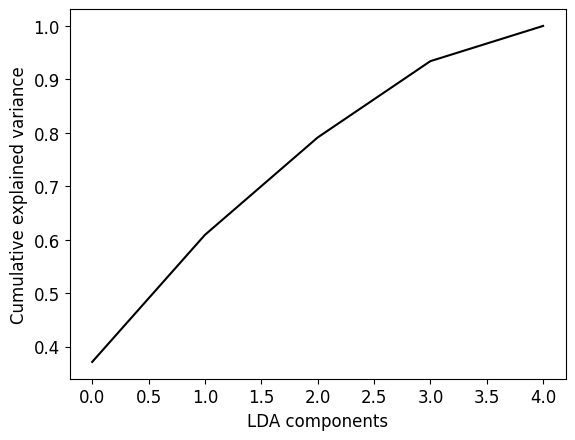

In [83]:
plt.plot(np.cumsum(lda.explained_variance_ratio_), color='black')
plt.ylabel('Cumulative explained variance')
plt.xlabel('LDA components')

# Train/ test mouse correlations

In [84]:
n_per_mouse = 3
lda_components = min_components

lda_to_check = 0

# final_matrix = np.array(norm_array)
# final_matrix = np.array(mat)
final_matrix = np.array(norm_pop)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]

n_samples = X.shape[0]
mouse_means = np.zeros(len(y)) * np.nan
ld_held_out = np.zeros(len(y)) * np.nan

# Subsample balanced sessions for training in each fold
for test_idx in range(n_samples):
    
    X_test = X[test_idx:test_idx+1]
    y_test = y[test_idx:test_idx+1]

    train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
    X_train_full = X[train_idx]
    y_train_full = y[train_idx]

    # --- balanced subsampling for training ---
    balanced_idx = []
    for m in np.unique(y_train_full):
        m_idx = np.where(y_train_full == m)[0]
        if len(m_idx) >= n_per_mouse:
            balanced_idx.extend(rng.choice(m_idx, n_per_mouse, replace=False))

    balanced_idx = np.array(balanced_idx)
    X_train = X_train_full[balanced_idx]
    y_train = y_train_full[balanced_idx]

    # --- true labels run ---
    lda = LinearDiscriminantAnalysis(
        priors=np.ones(len(np.unique(y_train))) / len(np.unique(y_train)),
        n_components=lda_components)
    
    lda.fit(X_train, y_train)
    transformed = lda.transform(X_train)
    mouse_means[test_idx] = np.mean(transformed[y_train == y_test, lda_to_check])  # LD1
    ld_held_out[test_idx] = lda.transform(X_test)[0][lda_to_check]  # if multiple sessions, take mean

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid valu

Text(0.05, 0.95, 'r = 0.745, p = 1.84e-33')

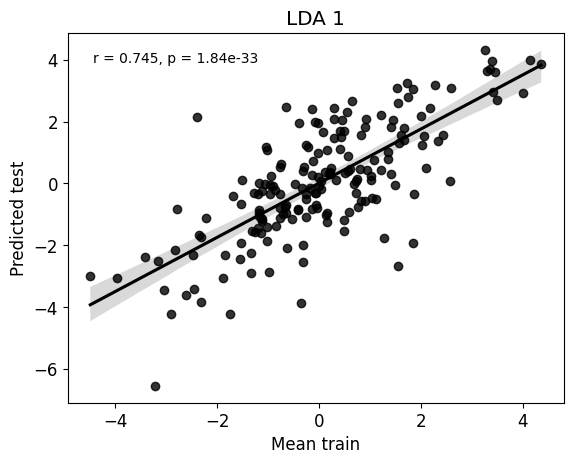

In [85]:
corr_df = pd.DataFrame(columns=['mean_train', 'transformed_test'])
corr_df['mean_train'] = mouse_means
corr_df['transformed_test'] = ld_held_out
corr_df = corr_df.dropna()

sns.regplot(x=np.array(corr_df['mean_train']).astype(float), y=corr_df['transformed_test'].astype(float), color='black', ci=95) 
plt.xlabel('Mean train')
plt.ylabel('Predicted test')
plt.title('LDA '+str(lda_to_check+1))

res = stats.pearsonr(np.array(corr_df['mean_train']).astype(float), corr_df['transformed_test'].astype(float))
plt.text(0.05, 0.95, f'r = {res.statistic:.3f}, p = {res.pvalue:.2e}',
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'train_test_corr.svg', format='svg', bbox_inches='tight')

# Correlate with training time

In [ ]:
path = prefix + 'representation_learning_variability/learning_prediction/'
# path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/training_data/'
# training_time = pd.read_parquet(path+'training_time_23-09-2025')
# training_time = pd.read_parquet(data_path+'training_time_23-03-2026')
training_time = pd.read_parquet(path+'training_time_27-04-2026')


In [88]:
var_name = 'training_days'
learning_df = clustered.merge(training_time, on='mouse_name')
learning_df['log_training'] = np.log(learning_df[var_name])

Text(0, 0.5, 'LDA component 2')

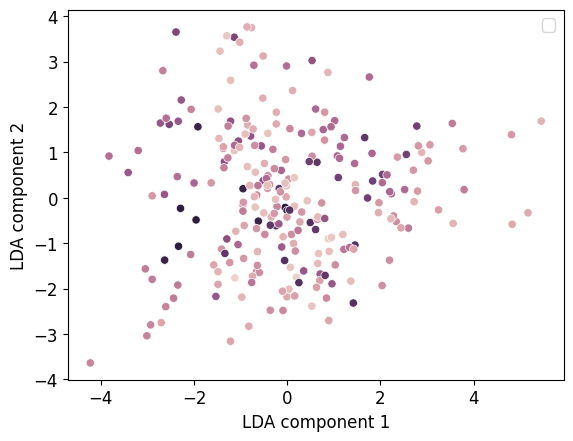

In [89]:
sns.scatterplot(x=0, y=1, hue=var_name, data=learning_df)
# plt.scatter(archetypes.T[0], archetypes.T[1], color='black', s=1)
# plt.plot(np.concatenate([archetypes.T[0], [archetypes.T[0][0]]]), np.concatenate([archetypes.T[1], [archetypes.T[1][0]]]), color='grey')
plt.legend('')
plt.xlabel('LDA component 1')
plt.ylabel('LDA component 2')

PearsonRResult(statistic=-0.1750591286303085, pvalue=0.2054703260529659)


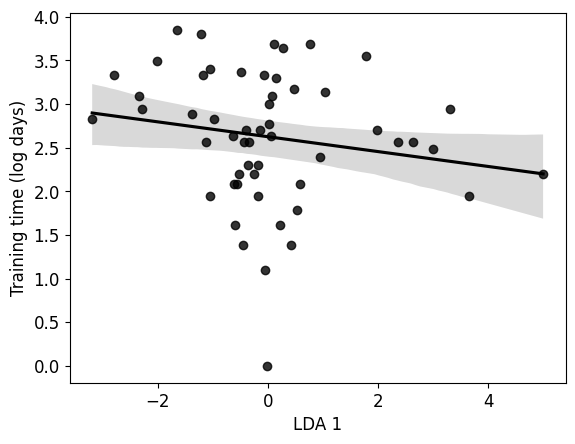

In [90]:
component = 0
group_df = learning_df.groupby(['mouse_name', var_name])[component].mean().reset_index()

sns.regplot(x=np.array(group_df[component]).astype(float), y=np.log(group_df[var_name]).astype(float), color='black', ci=95) 
plt.xlabel('LDA 1')
plt.ylabel('Training time (log days)')
plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'training_time_corre_lda1.svg', format='svg', bbox_inches='tight')

res = stats.pearsonr(np.array(group_df[component]).astype(float), np.log(group_df[var_name]).astype(float))
print(res)

PearsonRResult(statistic=np.float64(-0.4069312499228023), pvalue=np.float64(2.6156238864270942e-11))


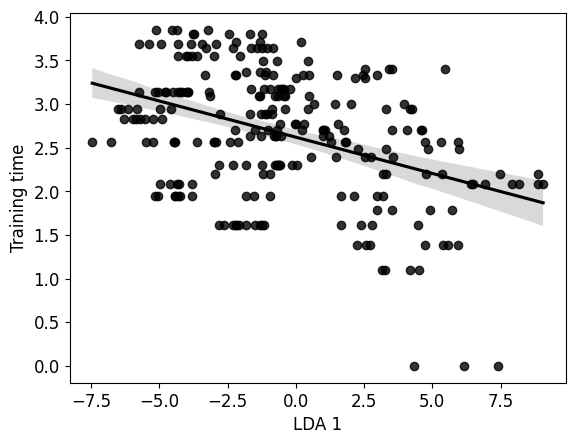

In [171]:
component = 0
group_df = learning_df.groupby(['mouse_name', var_name])[component].mean().reset_index()

sns.regplot(x=np.array(learning_df[component]).astype(float), y=np.log(learning_df[var_name]).astype(float), 
            color='black',ci=95) 
plt.xlabel('LDA 1')
plt.ylabel('Training time')

res = stats.pearsonr(np.array(learning_df[component]).astype(float), np.log(learning_df[var_name]).astype(float))
print(res)